# Ferrari Stock Analysis 2015-2026
Đây là dự án phân tích xu hướng, biến động và dự đoán xu hướng trong vòng 1 năm tiếp theo của cổ phiếu Ferrari.

Dự án tập trung vào 2 trường dữ liệu chính là 'Close','Date' đồng thời tiến hành làm mượt và lấy sai phân để phân tích/ dự đoán xu hướng giá đóng cửa của cổ phiếu RACE

In [1]:
# loading packeges
import numpy as np
import pandas as pd
import datetime as dt
import math 

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

# statistics
from scipy import stats

In [2]:
# Truy cap du lieu tu file CSV
data = pd.read_csv('D:\\data\\ferrari\\Ferrari History Stock Data.csv')

#### Exploration Data Analysis

1. Nghien cuu kieu du lieu
2. Phan tich xu huong (trends) gia dong cua cua du lieu
3. Nghien cuu khoi luong giao dich hang thang cua Ferrari Stock (MSA)
4. Kiem tra MA30, MA252 de nghien cuu trung binh dong cua gia theo xu huong ngan han va dai han
5. Tinh toan RSI cua bang du lieu

In [6]:
# Copy để tránh làm thay đổi dữ liệu gốc
fsa = data.copy()

# Hiển thị thông tin đồng thời kiểm tra dữ liệu bị thiếu (missing values)
print("Tong so dong va cot:", fsa.shape)
print(fsa.describe())
print('Tong so dong du lieu bi thieu (missing values): ', fsa.isnull().sum())

Tong so dong va cot: (2598, 6)
             Close         High          Low         Open        Volume
count  2598.000000  2598.000000  2598.000000  2598.000000  2.598000e+03
mean    212.158698   213.889960   210.419942   212.154888  4.709579e+05
std     132.058569   132.996605   131.097749   132.057662  6.197347e+05
min      29.582851    30.026594    29.268533    29.850947  5.380000e+04
25%     113.411070   114.653173   112.025279   113.923913  2.474000e+05
50%     185.648178   188.069001   183.788222   185.737501  3.504000e+05
75%     297.204849   298.811653   295.464965   296.458131  5.191250e+05
max     517.650024   519.099976   514.830017   515.000000  2.249880e+07
Tong so dong du lieu bi thieu (missing values):  Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [7]:
# Đổi kiểu dữ liệu của 'Date' thành datetime
fsa['Date'] = pd.to_datetime(fsa['Date'])
fsa.info()

<class 'pandas.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2598 non-null   datetime64[us]
 1   Close   2598 non-null   float64       
 2   High    2598 non-null   float64       
 3   Low     2598 non-null   float64       
 4   Open    2598 non-null   float64       
 5   Volume  2598 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 121.9 KB


In [8]:
# Kiểm tra dữ liệu đầu và cuối của tập dữ liệu
pd.concat([fsa.head(5), fsa.tail(5)])

,Date,Close,High,Low,Open,Volume
0,2015-10-21,50.845524,56.364575,50.845524,55.467844,22498800
1,2015-10-22,52.463337,53.803811,51.492650,52.759165,4545100
2,2015-10-23,52.121284,53.618915,52.019593,53.406289,1967600
3,2015-10-26,50.864014,52.694452,50.420271,52.694452,1466300
4,2015-10-27,49.782391,50.836283,45.631549,50.660632,5949200
2593,2026-02-13,379.079987,385.739990,377.660004,385.359985,1046900
2594,2026-02-17,374.989990,378.000000,372.589996,377.140015,576000
2595,2026-02-18,366.429993,370.290009,364.470001,365.450012,553300
2596,2026-02-19,366.500000,368.799988,359.750000,359.750000,804800
2597,2026-02-20,366.950012,368.260010,360.500000,360.500000,606900


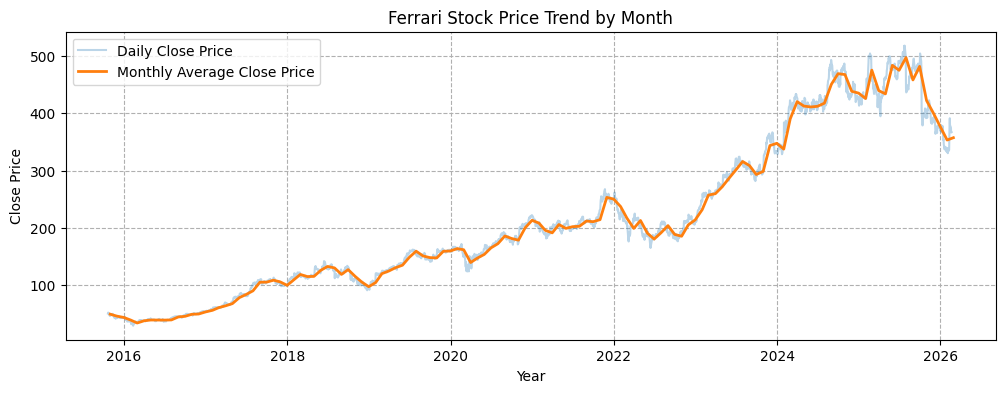

In [21]:
# Đảm bảo Date là datetime
fsa['Date'] = pd.to_datetime(fsa['Date'])

# Resample theo năm (KHÔNG cần set index)
ts_monthly = fsa.resample('ME', on='Date').mean()

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))

# Daily
plt.plot(fsa['Date'], fsa['Close'], 
         label='Daily Close Price', alpha=0.3)

# Monthly
plt.plot(ts_monthly.index, ts_monthly['Close'], 
         label='Monthly Average Close Price', linewidth=2)

plt.title('Ferrari Stock Price Trend by Month')
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

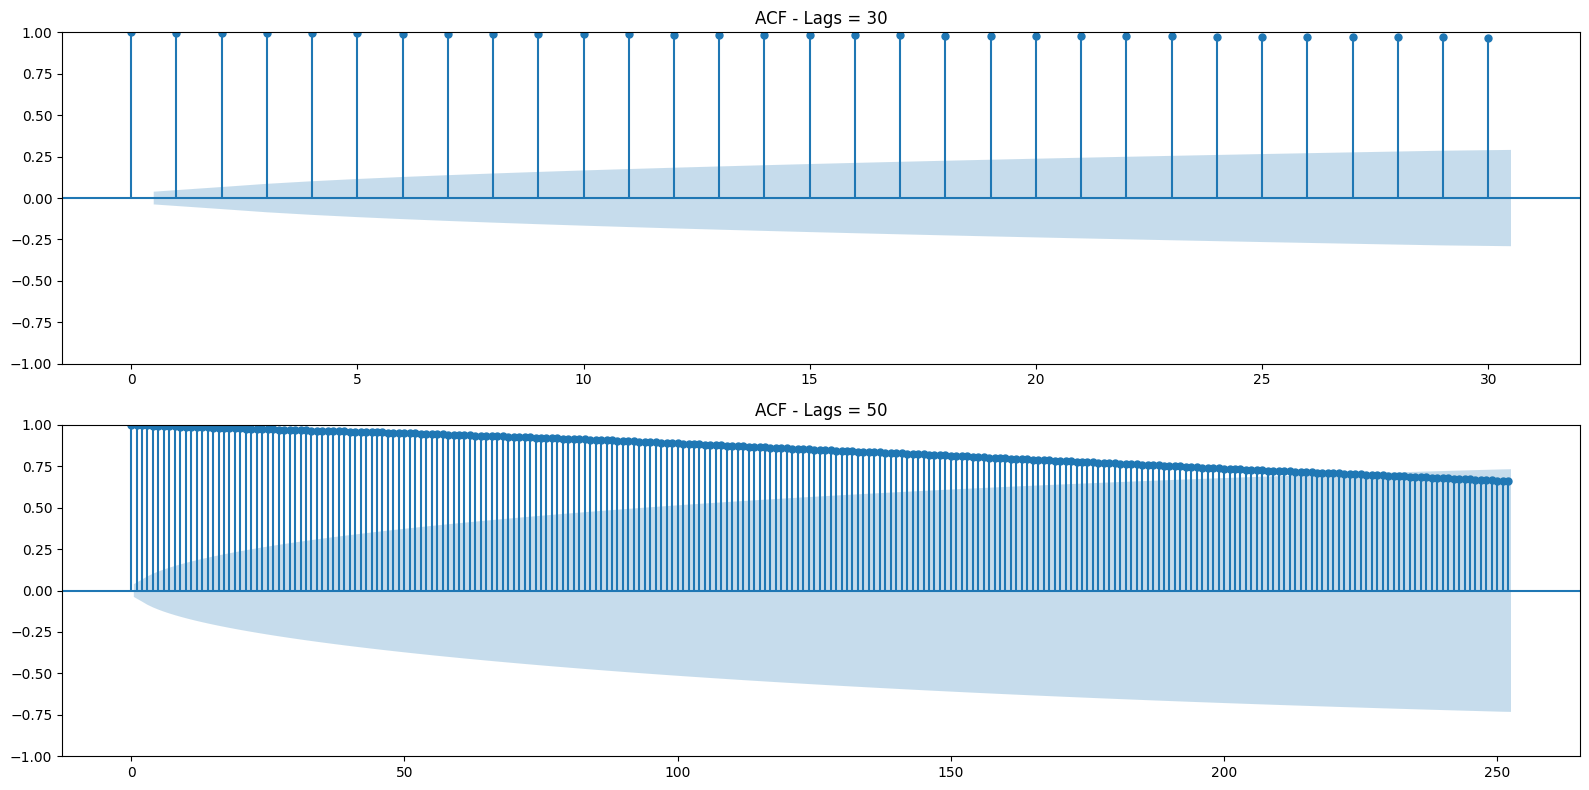

In [11]:
# Kiểm tra tính tương quan của dữ liệu bằng ACF

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Tương quan ngắn hạn
plot_acf(fsa['Close'], lags=30, ax=axes[0])
axes[0].set_title('ACF - Lags = 30')
# Tương quan dài hạn
plot_acf(fsa['Close'], lags=252, ax=axes[1])
axes[1].set_title('ACF - Lags = 50')

plt.tight_layout()
plt.show()

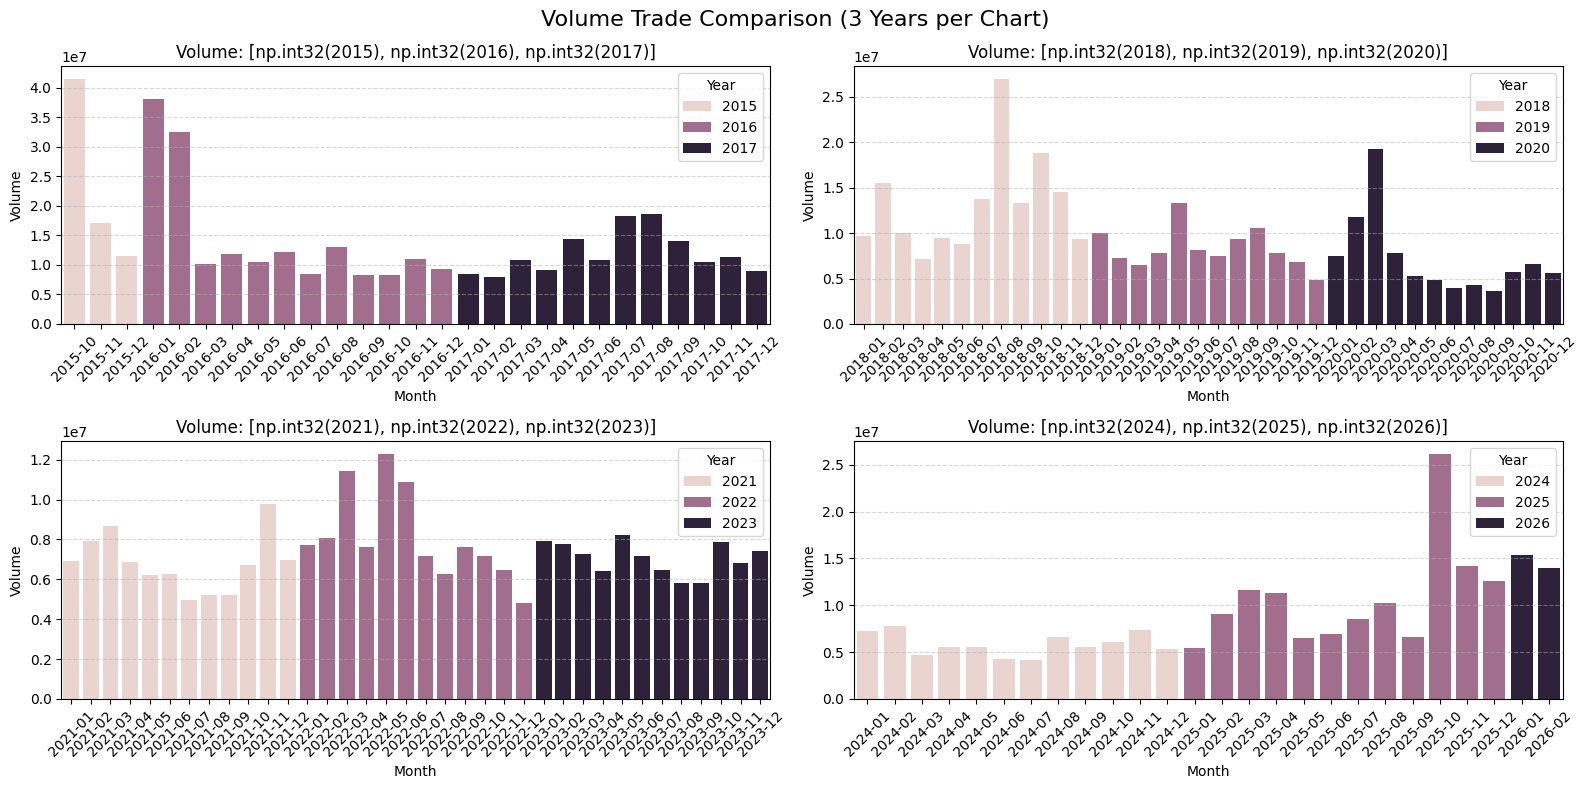

In [12]:
# Hiển thị dữ liệu khối lượng giao dịch trong khoảng 2015-2026
fsa['Year'] = fsa['Date'].dt.year
fsa['Month'] = fsa['Date'].dt.to_period('M')

monthly = (
    fsa.groupby(['Year', 'Month'])['Volume']
    .sum()
    .reset_index()
)

monthly['Month'] = monthly['Month'].astype(str)
years = sorted(monthly['Year'].unique())

# Chia bộ dữ liệu thành các nhóm 3 năm một với nhau (VD: 2015-2016-2017,...)
groups = [years[i:i+3] for i in range(0, len(years), 3)]

cols = 2
rows = math.ceil(len(groups) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows*4))
axes = axes.flatten()

for i, group in enumerate(groups):
    data = monthly[monthly['Year'].isin(group)]

    sns.barplot(
        ax=axes[i],
        data=data,
        x='Month',
        y='Volume',
        hue='Year'
    )

    axes[i].set_title(f'Volume: {group}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.5)

# Xoa o du
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Volume Trade Comparison (3 Years per Chart)', fontsize=16)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Moving Average Trends')

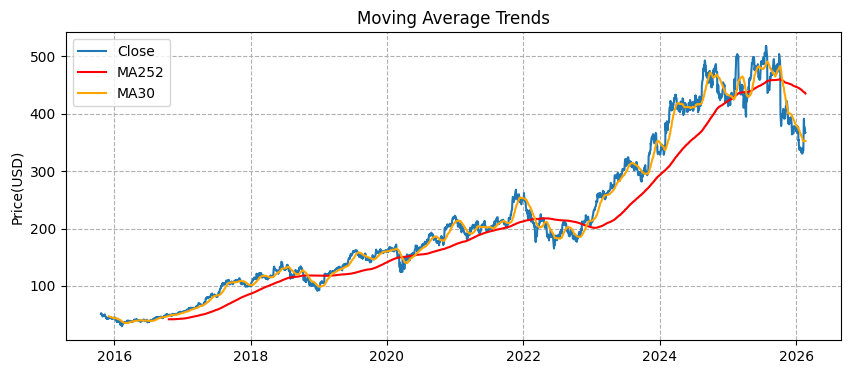

In [13]:
# Dùng MOVING AVERAGE để xác định trend dài hạn (MA252) và trend ngắn hạn (MA30)

plt.figure(figsize = (10, 4))

# MA30 & MA252
fsa['MA252'] = fsa['Close'].rolling(window=252).mean()
fsa['MA30'] = fsa['Close'].rolling(window=30).mean()
fsa['EMA30'] = fsa['Close'].ewm(span=30, adjust=False).mean()

plt.plot(fsa['Date'], fsa['Close'], label='Close')
plt.plot(fsa['Date'], fsa['MA252'], label='MA252', color = 'red')
plt.plot(fsa['Date'], fsa['MA30'], label='MA30', color = 'orange')
plt.ylabel('Price(USD)', loc='center')
plt.grid(True, linestyle = '--')
plt.legend()

plt.title('Moving Average Trends')

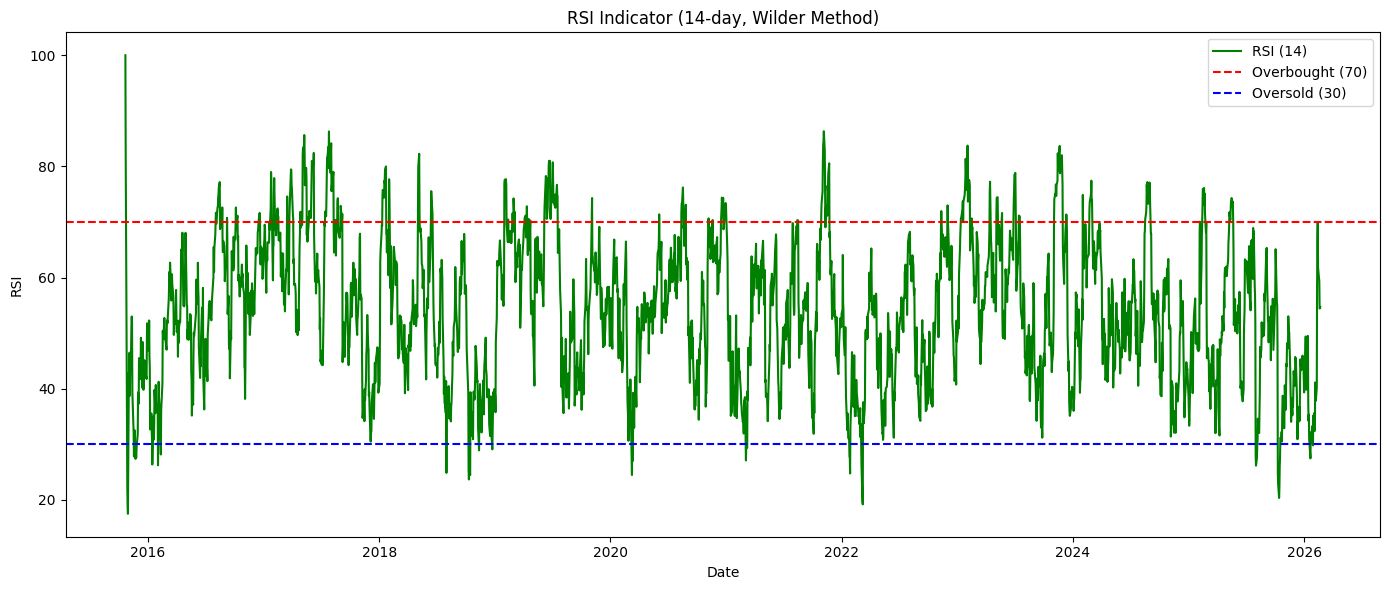

In [14]:
# Sai phân dữ liệu 'Close'  
delta = fsa['Close'].diff()

gain = (delta.where(delta > 0, 0))
loss = (-delta.where(delta < 0, 0))

# EMA theo chuẩn RSI
avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
# Exponential Moving Average (EMA) lam muot du lieu trong 14 phien gan nhat
# neu < 14 RSI nhay hon (Bien dong manh)
# neu > 14 -> RSI muot hon (it nhieu nhung phan ung cham)

rs = avg_gain / avg_loss
fsa['RSI'] = 100 - (100 / (1 + rs))

# Vẽ biểu đồ RSI
plt.figure(figsize=(14,6))

sns.lineplot(data=fsa, x='Date', y='RSI', color='green', label='RSI (14)')

# Ngưỡng quan trọng
plt.axhline(70, linestyle='--', color='red', label='Overbought (70)')
plt.axhline(30, linestyle='--', color='blue', label='Oversold (30)')

plt.title("RSI Indicator (14-day, Wilder Method)")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()
plt.tight_layout()
plt.show()

### Statistics

1. Tính toán giá trị Mean và Standard Deviation ở mức lags = 50 (ngày)
2. Kiểm tra trực quan 'tính Dừng' của dữ liệu
3. Tiến hành dùng ADF để phân tích dữ liệu có dừng hay không ?
    > Nếu p-value < 0.05 bác bỏ H0 -> Dãy dừng

In [18]:
# Sao dữ liệu gốc ra để tiến hành phân tích
dt = data.copy()

dt['Date'] = pd.to_datetime(dt['Date'])
dt.head(5)
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 2598 entries, 0 to 2597
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2598 non-null   datetime64[us]
 1   Close   2598 non-null   float64       
 2   High    2598 non-null   float64       
 3   Low     2598 non-null   float64       
 4   Open    2598 non-null   float64       
 5   Volume  2598 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 121.9 KB


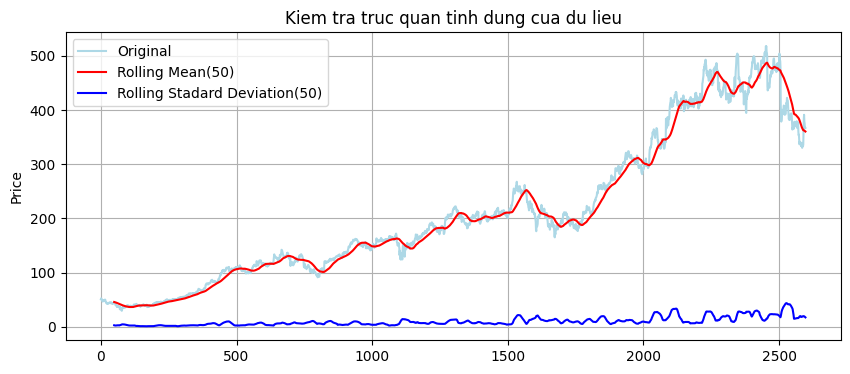

In [19]:
# Kiểm tra tính 'dừng' của dữ liệu

# Tinh toan mean va standard deviation
rolling_mean = dt['Close'].rolling(window= 50).mean()
rolling_std = dt['Close'].rolling(window= 50).std()

plt.figure(figsize = (10, 4))

plt.plot(dt['Close'], label = 'Original', color = 'lightblue')
plt.plot(rolling_mean, label = 'Rolling Mean(50)', color = 'red')
plt.plot(rolling_std, label = 'Rolling Stadard Deviation(50)', color = 'blue')
plt.ylabel('Price')
plt.title('Kiem tra truc quan tinh dung cua du lieu')
plt.grid()
plt.legend()

plt.show()

In [20]:
from statsmodels.tsa.stattools import adfuller

# Kiểm tra tính dừng của dữ liệu bằng ADF
result = adfuller(dt['Close'])
print("\nKết quả kiểm tra ADF:")
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print('Kết luận: Dãy số thời gian có tính dừng' if result[1] < 0.05 else 'Kết luận: Dãy số thời gian không có tính dừng')

# Dãy không dừng, lấy sai phân (differencing) để xét dãy có dừng không
if result[1]>= 0.05:
    dt_diff = dt['Close'].diff().dropna()
    result_diff = adfuller(dt_diff)
    print("\nKết quả sau khi lấy sai phân:")
    print(f'ADF Statistic: {result_diff[0]}')
    print(f'p-value: {result_diff[1]}')
    print('Kết luận: Dãy số thời gian có tính dừng' if result_diff[1] < 0.05 else 'Kết luận: Dãy số thời gian không có tính dừng')


Kết quả kiểm tra ADF:
ADF Statistic: -0.8316171355795957
p-value: 0.8096579281136709
Kết luận: Dãy số thời gian không có tính dừng

Kết quả sau khi lấy sai phân:
ADF Statistic: -10.489987616713197
p-value: 1.1536907521295334e-18
Kết luận: Dãy số thời gian có tính dừng


### Phân rã dãy số

Y(t) = Trend + Seasonality + Residual
1. Trend: Xu hướng (tăng, giảm hay ổn định)
2. Seasonality(Tính mùa vụ): Mẫu lặp theo chu kỳ cố định (tháng, quý, ...)
3. Cyclic(Chu kỳ): Dao động dài hạn không đều
4. Noise: Phần không giải thích đc bởi trend hay seasonality. Ngẫu nhiên và ko có quy luật

In [5]:
# tìm seasonality
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import periodogram
# dùng HP Filter  tìm chu kỳ dài Cycle
from statsmodels.tsa.filters.hp_filter import hpfilter
from scipy import signal

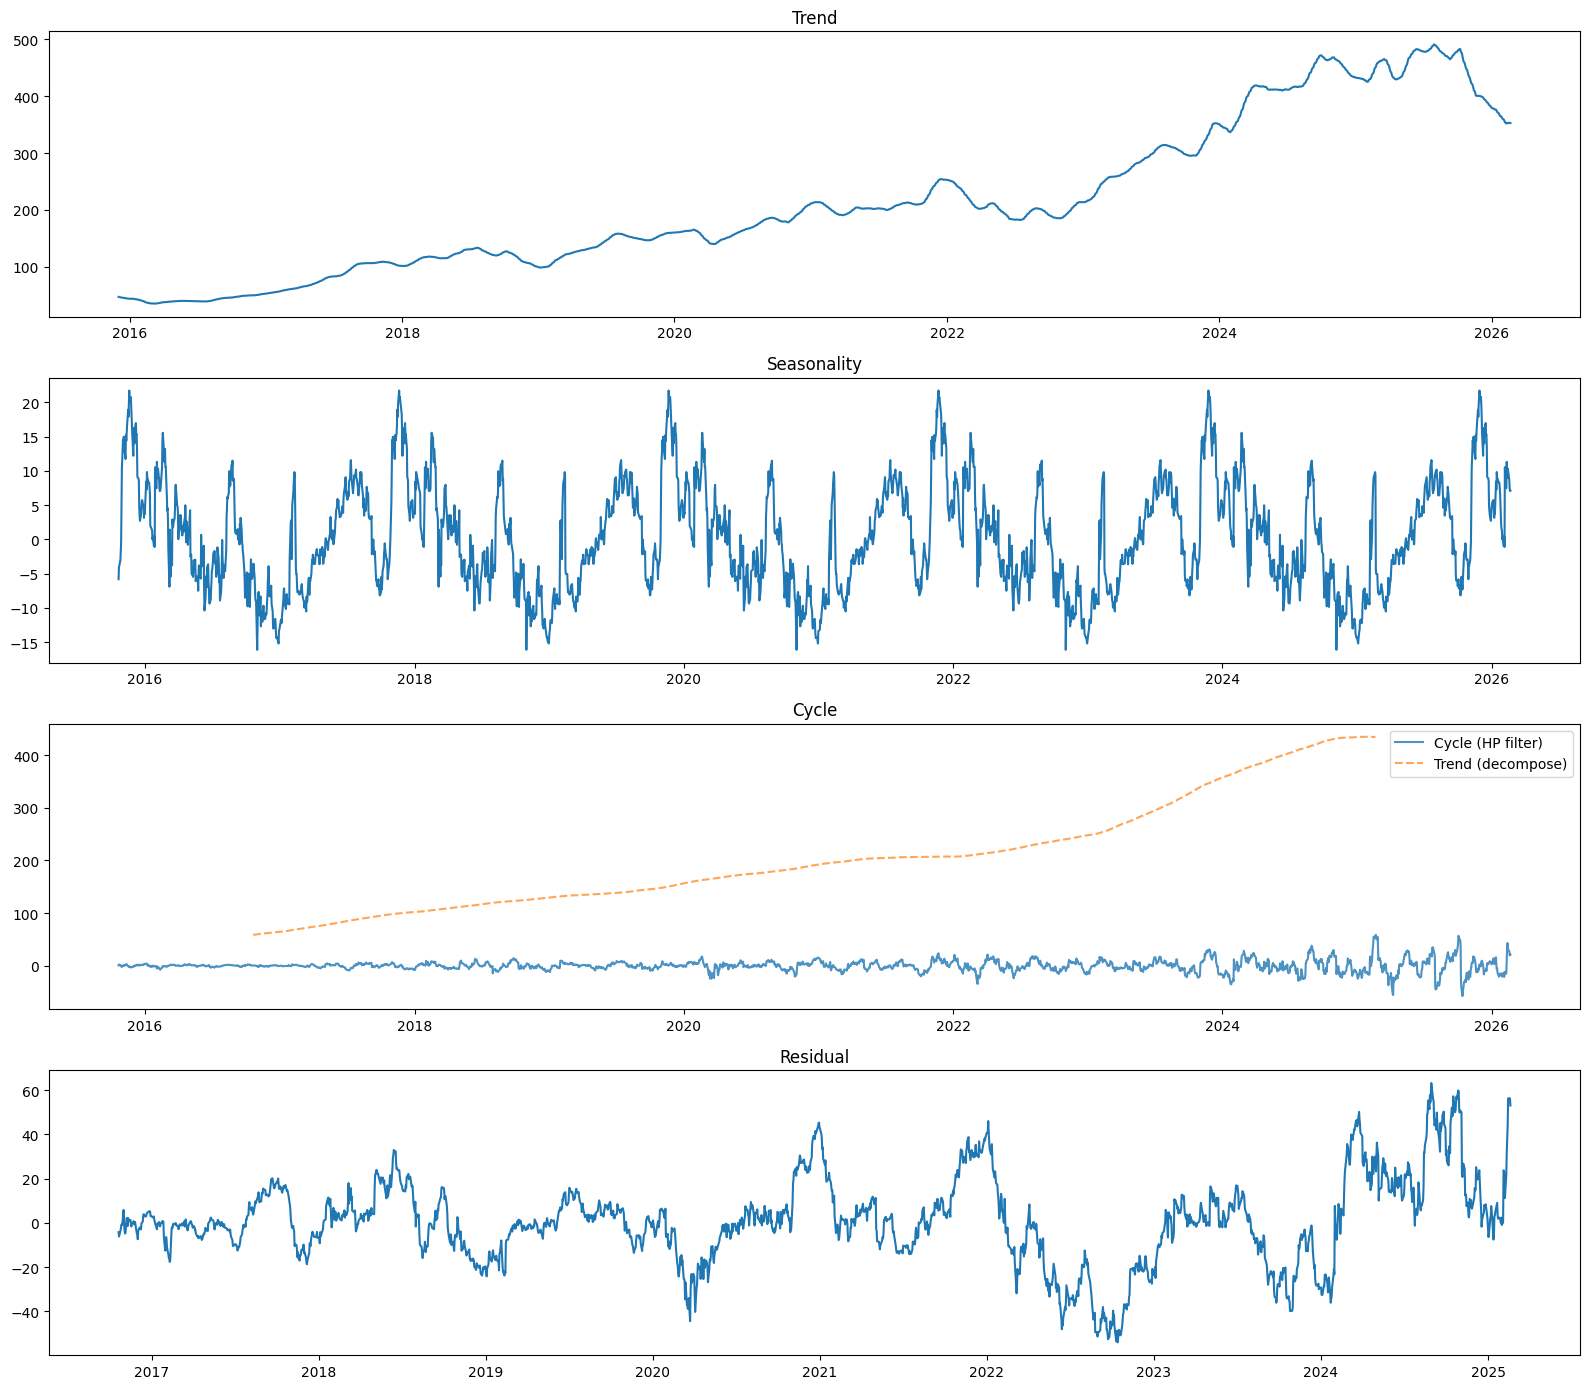

In [8]:
# Dùng Periodogram tìm seasonality
diff = dt['Close'].diff().dropna()
trend = dt['Close'].rolling(30).mean()

fig, axes = plt.subplots(4, 1, figsize = (16, 14))
axes = axes.flatten()

# hiển thị Trend của dữ liệu
axes[0].plot(dt['Date'], trend, label = 'Trend(30)')
axes[0].set_title('Trend')

# hiển thị Seasonality
seasonality = seasonal_decompose(dt['Close'], model='additive', period=252*2)
seasonal = seasonality.seasonal
axes[1].plot(dt['Date'], seasonal)
axes[1].set_title('Seasonality')

# ***hiển thị chu kỳ dài Cycle bằng HP filter + seasonal_decompose
cycle_hp, trend_hp = hpfilter(dt['Close'], lamb=129600)
# Định nghĩa cycle theo HP filter và trend theo seasonal decompose
cycle = cycle_hp
axes[2].plot(dt['Date'], cycle, label='Cycle (HP filter)', alpha=0.8)
axes[2].plot(dt['Date'], seasonality.trend, label='Trend (decompose)', linestyle='--', alpha=0.7)
axes[2].set_title('Cycle')
axes[2].legend()

# hiển thị Residual (Noise) với NaN đã bị loại
noise = seasonality.resid.dropna()
axes[3].plot(dt.loc[noise.index, 'Date'], noise)
axes[3].set_title('Residual')

plt.tight_layout()
plt.show()

DO dư liệu đc đo bởi ADF p-value < 0.05 nên dữ liệu có tính dừng, ta sử dụng ARIMA để tiến hành dự đoán ngắn hạn

#### Phân tích ảnh hưởng của CoVID-19 lên Ferarri Stock

In [4]:
# lấy dữ liệu
dt = data.copy()

In [7]:
dt['Date'] = pd.to_datetime(dt['Date'])
fsa_19 = dt[(dt['Date'] >= '2019-12-01') & (dt['Date'] <= '2023-05-31')]